In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns
print("Libraries imported successfully")

Libraries imported successfully


In [2]:
%matplotlib inline
plt.style.use('default')  # Ensures clean plotting environment

In [3]:
# Defining global variables
color_teal = '#008080'  # Teal color for plots
color_blue = '#4B8BBE'  # Blue color for plots
color_purple = '#6A5ACD'  # Purple color for plots
color_orange = '#FF8C00'  # Orange color for plots

### First we will get some insight from our customers data

In [4]:
# Load customer data from the database
conn = sqlite3.connect('fraud_detection.db')
customers_df = pd.read_sql_query("SELECT * FROM customers", conn)

In [28]:
conn.close()

In [5]:
customers_df.head()

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,acct_num,pop_group,location
0,115-04-4507,4218196001337,Kathy,Johnson,F,863 Lawrence Valleys,Staten Island,NY,10302,40.630600,-74.137901,468730,Accounting technician,1982-10-03,888022315787,adults_2550,urban
1,715-55-5575,4351161559407816183,Elaine,Fuller,F,310 Kendra Common Apt. 164,Peabody,MA,1960,42.532600,-70.961197,50944,Professor Emeritus,1994-06-07,917558277935,adults_2550,urban
2,167-48-5821,4192832764832,Melinda,Cameron,F,05641 Robin Port,Waukomis,OK,73773,36.278099,-97.899597,1744,International aid/development worker,1934-05-30,718172762479,adults_50up,rural
3,406-83-7518,4238849696532874,Brandon,Williams,M,26916 Carlson Mountain,Los Angeles,CA,90019,34.048199,-118.334297,2383912,Seismic interpreter,1991-12-26,947268892251,adults_2550,urban
4,697-93-1877,4514627048281480,Lisa,Hernandez,F,809 Burns Creek,Austin,TX,78727,30.425400,-97.719498,940359,Medical laboratory scientific officer,1998-05-22,888335239225,adults_2550,urban


Customers - Preliminary Demographics Analysis:


Population Group Distribution:
  adults_50up: 516 (51.1%)
  adults_2550: 401 (39.7%)
  young_adults: 93 (9.2%)

Location Distribution:
  urban: 969 (95.9%)
  rural: 41 (4.1%)


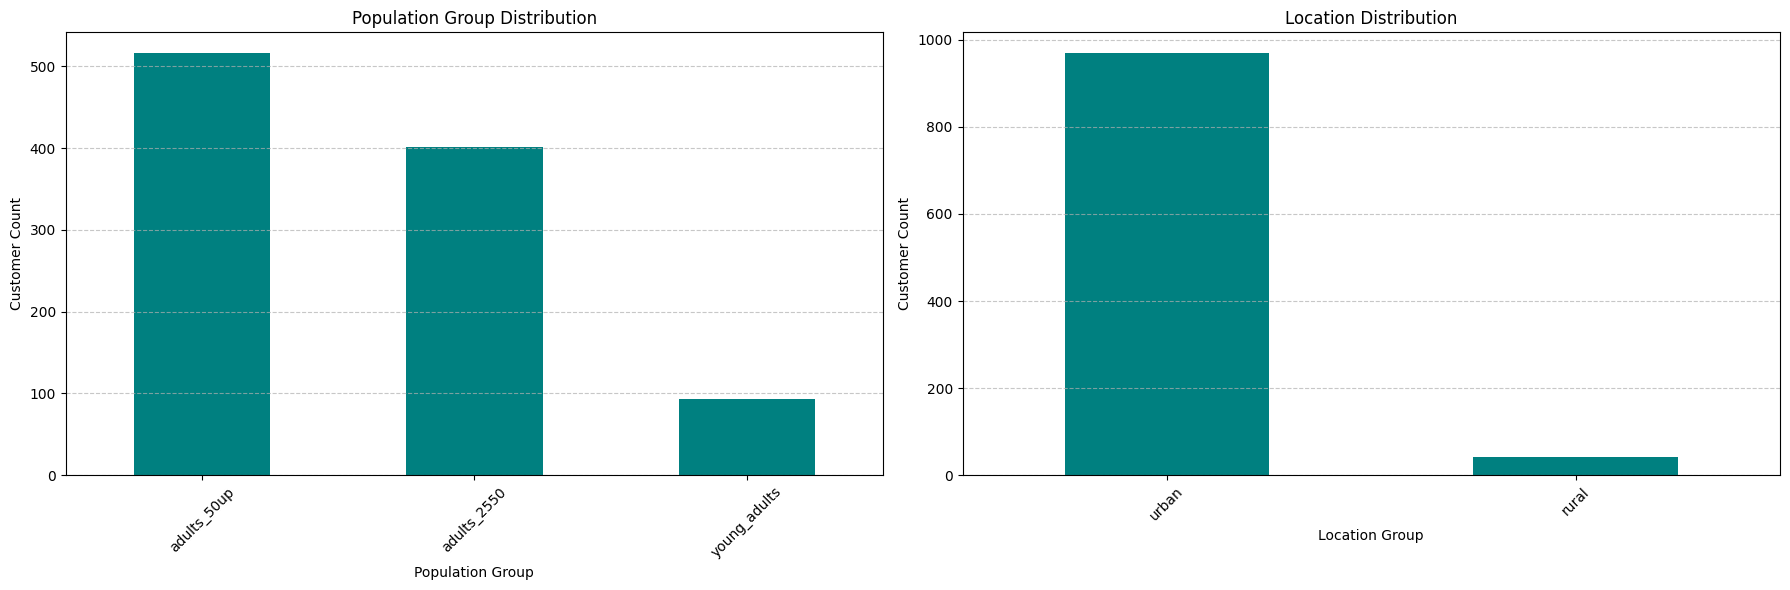

In [ ]:
# Customer demographics analysis - Using a bar plot
print("Customers - Preliminary Demographics Analysis:\n")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Population group distribution
profile_dist = customers_df['pop_group'].value_counts()
print(f"\nPopulation Group Distribution:")
for profile, count in profile_dist.items():
    print(f"  {profile}: {count} ({count/len(customers_df)*100:.1f}%)")

# Plotting using a bar plot
profile_dist.plot( kind='bar',color=color_teal,ax=axes[0]
)
axes[0].set_title('Population Group Distribution')
axes[0].set_xlabel('Population Group')
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability
axes[0].grid(axis='y', linestyle='--', alpha=0.7) # Add grid lines for better visualization

# Location distribution

location_dist = customers_df['location'].value_counts()
print(f"\nLocation Distribution:")
for location, count in location_dist.items():
    print(f"  {location}: {count} ({count/len(customers_df)*100:.1f}%)")

# Plotting
location_dist.plot(
    kind='bar',
    color=color_teal,
    ax=axes[1]
)
axes[1].set_title('Location Distribution')
axes[1].set_xlabel('Location Group')
axes[1].set_ylabel('Customer Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Customers - Preliminary Demographics Analysis:


Population Group Distribution:
  adults_50up: 516 (51.1%)
  adults_2550: 401 (39.7%)
  young_adults: 93 (9.2%)

Location Distribution:
  urban: 969 (95.9%)
  rural: 41 (4.1%)

Gender Distribution:
  M: 531 (52.6%)
  F: 479 (47.4%)


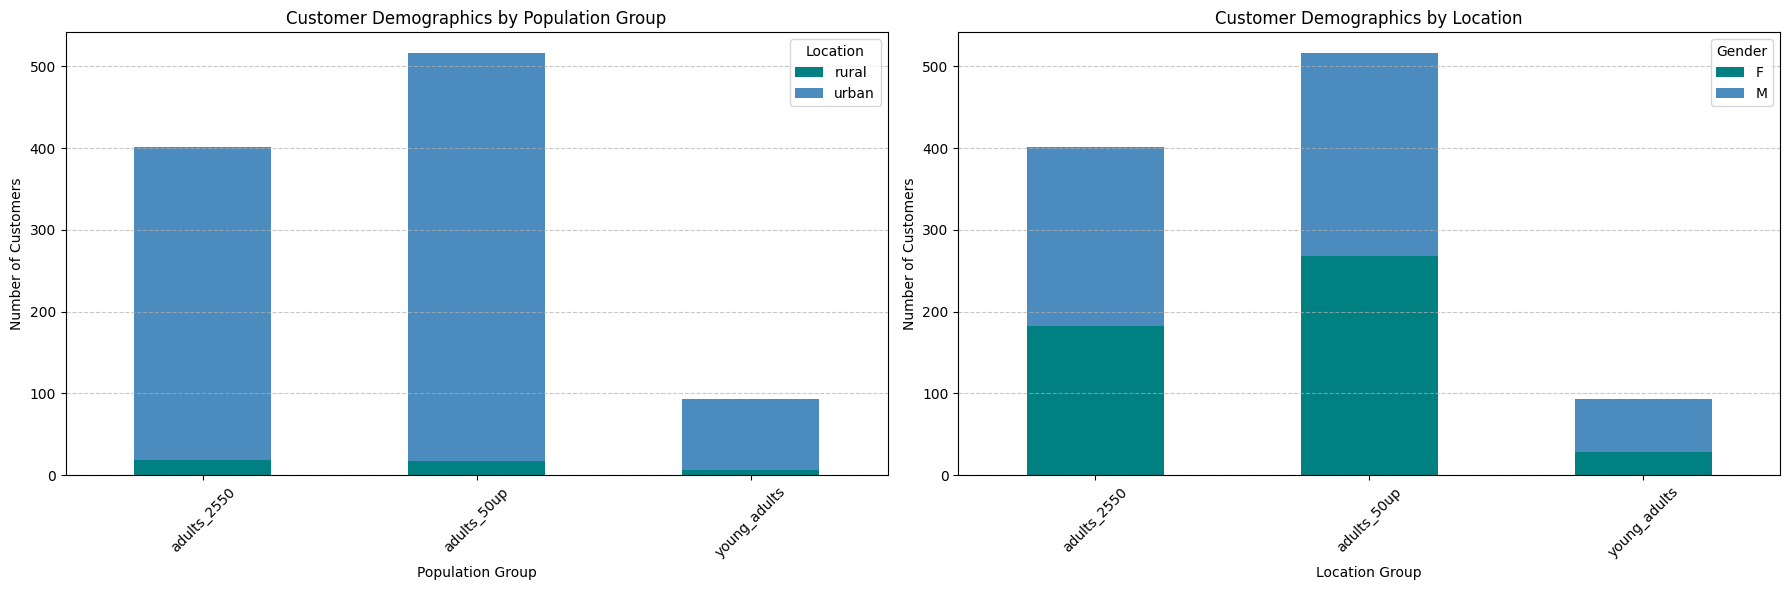

In [ ]:
# Customer demographics analysis - Using an stacked bar plot
print("Customers - Preliminary Demographics Analysis:\n")

# Population group distribution
profile_dist = customers_df['pop_group'].value_counts()
print(f"\nPopulation Group Distribution:")
for profile, count in profile_dist.items():
    print(f"  {profile}: {count} ({count/len(customers_df)*100:.1f}%)")

location_dist = customers_df['location'].value_counts()
print(f"\nLocation Distribution:")
for location, count in location_dist.items():
    print(f"  {location}: {count} ({count/len(customers_df)*100:.1f}%)")

gender_dist = customers_df['gender'].value_counts()
print(f"\nGender Distribution:")
for gender, count in gender_dist.items():
    print(f"  {gender}: {count} ({count/len(customers_df)*100:.1f}%)")

# Plotting Groups/Locations
# Create cross-tabulation
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html
# https://www.geeksforgeeks.org/python/pandas-crosstab-function-in-python/

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
customers_cross_loc = pd.crosstab(customers_df['pop_group'], customers_df['location'])

customers_cross_loc.plot(kind='bar', stacked=True, color=[color_teal, color_blue], ax=axes[0])
axes[0].set_title('Customer Demographics by Population Group')
axes[0].set_xlabel('Population Group')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Location')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
# Location distribution



# Plotting
customers_cross_gender = pd.crosstab(customers_df['pop_group'], customers_df['gender'])
customers_cross_gender.plot(kind='bar', stacked=True, color=[color_teal, color_blue], ax=axes[1])

axes[1].set_title('Customer Demographics by Location')
axes[1].set_xlabel('Location Group')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Gender')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

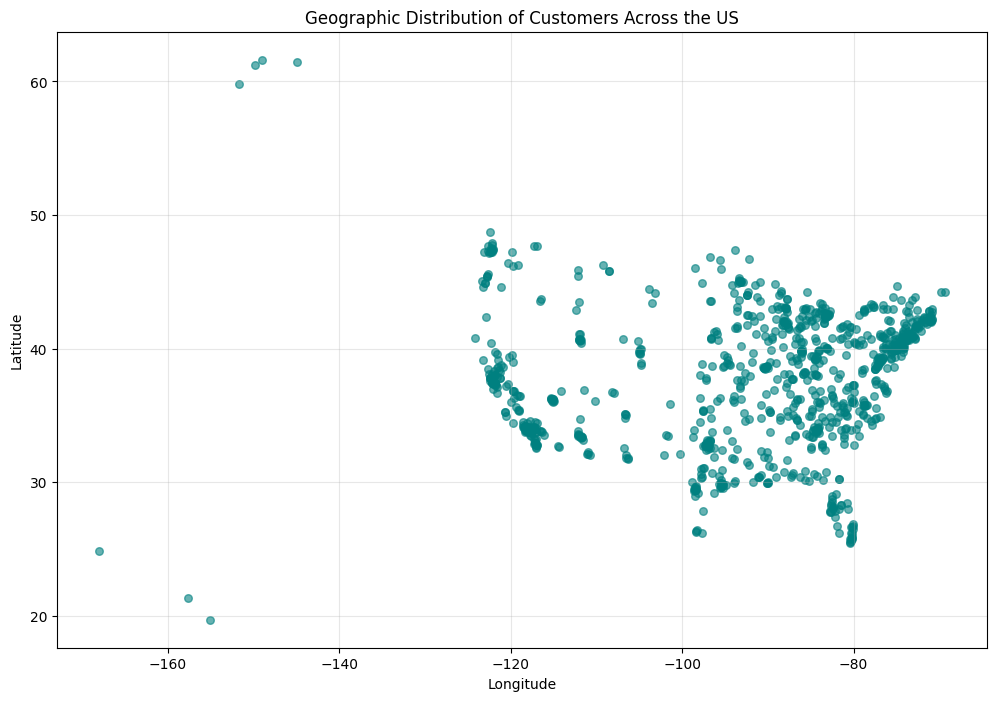

In [10]:
# Geographic distribution
plt.figure(figsize=(12, 8))
plt.scatter(customers_df['long'], customers_df['lat'], 
           c=color_teal,  alpha=0.6, s=30)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Customers Across the US')
plt.grid(True, alpha=0.3)
plt.show()


Top 10 States by Customer Count:
  CA: 132 customers
  TX: 80 customers
  NY: 63 customers
  FL: 48 customers
  PA: 47 customers
  MI: 39 customers
  NC: 34 customers
  OH: 31 customers
  IL: 30 customers
  GA: 29 customers


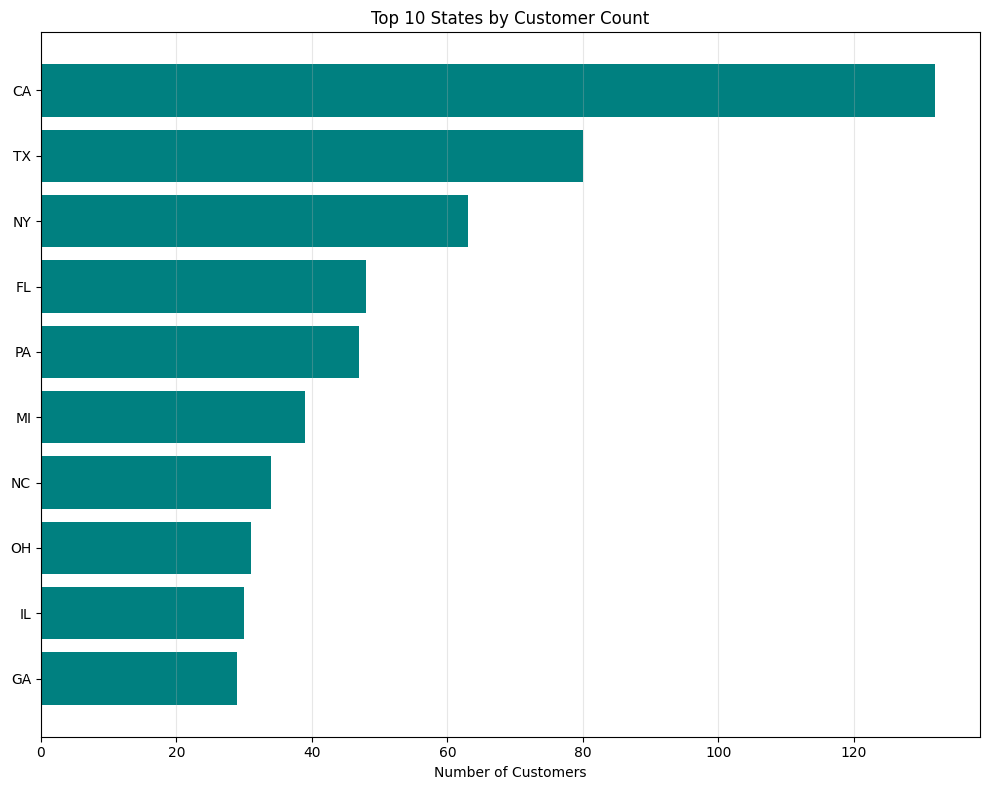

In [27]:
# Geographic distribution

num_states_viz = 10
state_counts = customers_df['state'].value_counts().head(num_states_viz)

print(f"\nTop {num_states_viz} States by Customer Count:")
for state, count in state_counts.items():
    print(f"  {state}: {count} customers")
    
plt.figure(figsize=(10, 8))
plt.barh(range(len(state_counts)), state_counts.values, color=color_teal)
plt.yticks(range(len(state_counts)), state_counts.index)
plt.xlabel('Number of Customers')
plt.title(f'Top {num_states_viz} States by Customer Count')
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()  # Put highest at top
plt.tight_layout()
plt.show()

### Transaction analysis

In [ ]:
# Load transaction data from the database
transactions_df = pd.read_sql_query("SELECT * FROM transactions", conn)

In [ ]:
uf.show_df_info(transactions_df)

In [ ]:
# Transaction analysis from sample
print("**** TRANSACTION ANALYSIS (Sample) ****\n")

# Transaction categories
if 'category' in sample_transactions_df.columns:
    category_dist = sample_transactions_df['category'].value_counts()
    print(f"\nTransaction Categories (from sample file):")
    for category, count in category_dist.items():
        print(f"  {category}: {count} ({count/len(sample_transactions_df)*100:.1f}%)")

# Amount statistics
if 'amt' in sample_transactions_df.columns:
    print(f"\nTransaction Amount Statistics (from sample):")
    print(f"  Mean: ${sample_transactions_df['amt'].mean():.2f}")
    print(f"  Median: ${sample_transactions_df['amt'].median():.2f}")
    print(f"  Min: ${sample_transactions_df['amt'].min():.2f}")
    print(f"  Max: ${sample_transactions_df['amt'].max():.2f}")
    print(f"  Std Dev: ${sample_transactions_df['amt'].std():.2f}")

# Fraud statistics
if 'is_fraud' in sample_transactions_df.columns:
    fraud_dist = sample_transactions_df['is_fraud'].value_counts()
    fraud_rate = fraud_dist.get(1, 0) / len(sample_transactions_df) * 100
    print(f"\nFraud Statistics (from sample):")
    print(f"  Legitimate Transactions: {fraud_dist.get(0, 0)}")
    print(f"  Fraudulent Transactions: {fraud_dist.get(1, 0)}")
    print(f"  Fraud Rate: {fraud_rate:.2f}%")